# Evaluating Large Language Models: From BLEU to LLM-as-a-Judge

Training is finished. Serving is deployed.

Now the engineering question becomes:

> How do we know whether the model is actually good?

Evaluation is the bridge between a model that runs and a model that is ready for users. It helps us understand whether an LLM is accurate, useful, reliable, consistent, and safe.


## Notebook Roadmap

This notebook moves from classical NLP metrics to modern LLM evaluation practice:

- perplexity for language modeling quality
- BLEU and ROUGE for overlap-based evaluation
- embedding similarity for semantic comparison
- hallucination and factuality checks
- human evaluation rubrics
- LLM-as-a-Judge workflows
- production monitoring and deployment decisions


In [1]:
import os
from collections import Counter
from pathlib import Path
import math
import re

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.2,
    "font.size": 11,
})

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


Matplotlib is building the font cache; this may take a moment.


In [2]:
def tokenize(text):
    """Tokenize text into lowercase word tokens for lightweight examples."""
    return re.findall(r"\b\w+\b", text.lower())


def check_package(package_name):
    """Return True when a Python package can be imported."""
    import importlib.util

    return importlib.util.find_spec(package_name) is not None


packages = {
    "numpy": check_package("numpy"),
    "pandas": check_package("pandas"),
    "matplotlib": check_package("matplotlib"),
    "nltk": check_package("nltk"),
    "rouge_score": check_package("rouge_score"),
    "sklearn": check_package("sklearn"),
    "sentence_transformers": check_package("sentence_transformers"),
}

pd.DataFrame([{"Package": name, "Available": ok} for name, ok in packages.items()])


,Package,Available
0,numpy,True
1,pandas,True
2,matplotlib,True
3,nltk,False
4,rouge_score,False
5,sklearn,True
6,sentence_transformers,True


In [3]:
missing_optional = [name for name in ["nltk", "rouge_score", "sentence_transformers"] if not packages[name]]

if missing_optional:
    print("Optional evaluation libraries missing:", ", ".join(missing_optional))
    print("Install when needed with:")
    print("pip install nltk rouge-score sentence-transformers")
else:
    print("All optional evaluation libraries are available.")


Optional evaluation libraries missing: nltk, rouge_score
Install when needed with:
pip install nltk rouge-score sentence-transformers


## Why Evaluation Matters

An LLM can produce fluent text and still be wrong. It can score well on an overlap metric and still hallucinate. It can pass a benchmark and fail on the exact business workflow that users care about.

Evaluation matters because it turns vague impressions into engineering signals:

- Can the model answer correctly?
- Does it follow instructions?
- Does it stay grounded in the provided context?
- Does it behave consistently across similar inputs?
- Does it avoid unsafe or misleading responses?


In [4]:
examples = pd.DataFrame([
    {
        "Scenario": "Fluent but false",
        "Model Output": "The Eiffel Tower is located in Berlin.",
        "Why It Matters": "Fluency does not imply factuality.",
    },
    {
        "Scenario": "High overlap, low usefulness",
        "Model Output": "Refund policy refund policy customer refund.",
        "Why It Matters": "N-gram overlap can reward repeated words.",
    },
    {
        "Scenario": "Helpful but risky",
        "Model Output": "Here is a confident answer without citing the provided source.",
        "Why It Matters": "Useful tone can hide unsupported claims.",
    },
])
examples


,Scenario,Model Output,Why It Matters
0,Fluent but false,The Eiffel Tower is located in Berlin.,Fluency does not imply factuality.
1,"High overlap, low usefulness",Refund policy refund policy customer refund.,N-gram overlap can reward repeated words.
2,Helpful but risky,Here is a confident answer without citing the ...,Useful tone can hide unsupported claims.


In [5]:
evaluation_types = pd.DataFrame([
    {
        "Type": "Intrinsic Evaluation",
        "Question": "How good is the model internally?",
        "Examples": "Perplexity, next-token prediction",
        "Used For": "Model development and pretraining checks",
    },
    {
        "Type": "Extrinsic Evaluation",
        "Question": "How well does it perform in a real task?",
        "Examples": "Support resolution, summarization quality",
        "Used For": "Application-level validation",
    },
    {
        "Type": "Human Evaluation",
        "Question": "Do people judge the answer as good?",
        "Examples": "Rubrics, pairwise preference",
        "Used For": "Quality, trust, safety, preference",
    },
    {
        "Type": "LLM-as-a-Judge",
        "Question": "Can another model grade the output?",
        "Examples": "Rubric scoring, pairwise comparison",
        "Used For": "Scalable review before human spot checks",
    },
    {
        "Type": "Task-Specific Evaluation",
        "Question": "Does it solve this exact use case?",
        "Examples": "SQL validity, code tests, retrieval faithfulness",
        "Used For": "Product readiness",
    },
    {
        "Type": "Production Monitoring",
        "Question": "Is quality stable after deployment?",
        "Examples": "Feedback, drift, latency, incidents",
        "Used For": "Continuous improvement",
    },
])

evaluation_types


,Type,Question,Examples,Used For
0,Intrinsic Evaluation,How good is the model internally?,"Perplexity, next-token prediction",Model development and pretraining checks
1,Extrinsic Evaluation,How well does it perform in a real task?,"Support resolution, summarization quality",Application-level validation
2,Human Evaluation,Do people judge the answer as good?,"Rubrics, pairwise preference","Quality, trust, safety, preference"
3,LLM-as-a-Judge,Can another model grade the output?,"Rubric scoring, pairwise comparison",Scalable review before human spot checks
4,Task-Specific Evaluation,Does it solve this exact use case?,"SQL validity, code tests, retrieval faithfulness",Product readiness
5,Production Monitoring,Is quality stable after deployment?,"Feedback, drift, latency, incidents",Continuous improvement


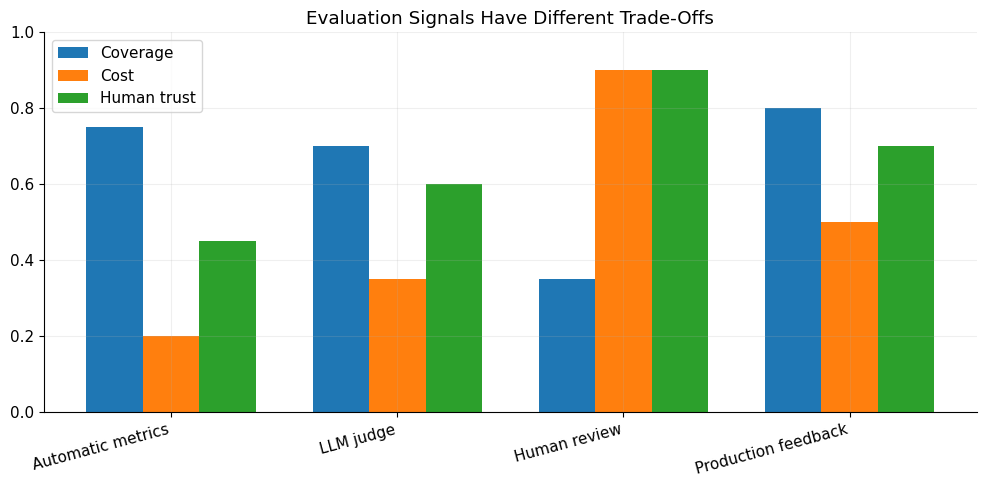

In [6]:
metric_scores = pd.DataFrame([
    {"Signal": "Automatic metrics", "Coverage": 0.75, "Cost": 0.20, "Human trust": 0.45},
    {"Signal": "LLM judge", "Coverage": 0.70, "Cost": 0.35, "Human trust": 0.60},
    {"Signal": "Human review", "Coverage": 0.35, "Cost": 0.90, "Human trust": 0.90},
    {"Signal": "Production feedback", "Coverage": 0.80, "Cost": 0.50, "Human trust": 0.70},
])

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metric_scores))
width = 0.25
for i, col in enumerate(["Coverage", "Cost", "Human trust"]):
    ax.bar(x + (i - 1) * width, metric_scores[col], width, label=col)
ax.set_xticks(x)
ax.set_xticklabels(metric_scores["Signal"], rotation=15, ha="right")
ax.set_ylim(0, 1)
ax.set_title("Evaluation Signals Have Different Trade-Offs")
ax.legend()
plt.tight_layout()
plt.show()


## Perplexity

Perplexity measures how surprised a language model is by a sequence of tokens. Lower perplexity generally means the model assigned higher probability to the observed text.

Intuitively:

- confident correct predictions produce lower perplexity
- uncertain predictions produce higher perplexity
- very low perplexity on training data can also indicate memorization or overfitting


In [7]:
def perplexity(token_probabilities):
    """Compute perplexity from a list of predicted token probabilities."""
    probs = np.clip(np.array(token_probabilities, dtype=float), 1e-12, 1.0)
    return float(np.exp(-np.mean(np.log(probs))))


good_model_probs = [0.82, 0.70, 0.65, 0.90, 0.76]
weak_model_probs = [0.32, 0.18, 0.40, 0.25, 0.30]

perplexity_table = pd.DataFrame([
    {"Model": "Good toy model", "Token Probabilities": good_model_probs, "Perplexity": perplexity(good_model_probs)},
    {"Model": "Weak toy model", "Token Probabilities": weak_model_probs, "Perplexity": perplexity(weak_model_probs)},
])
perplexity_table


,Model,Token Probabilities,Perplexity
0,Good toy model,"[0.82, 0.7, 0.65, 0.9, 0.76]",1.314086
1,Weak toy model,"[0.32, 0.18, 0.4, 0.25, 0.3]",3.568546


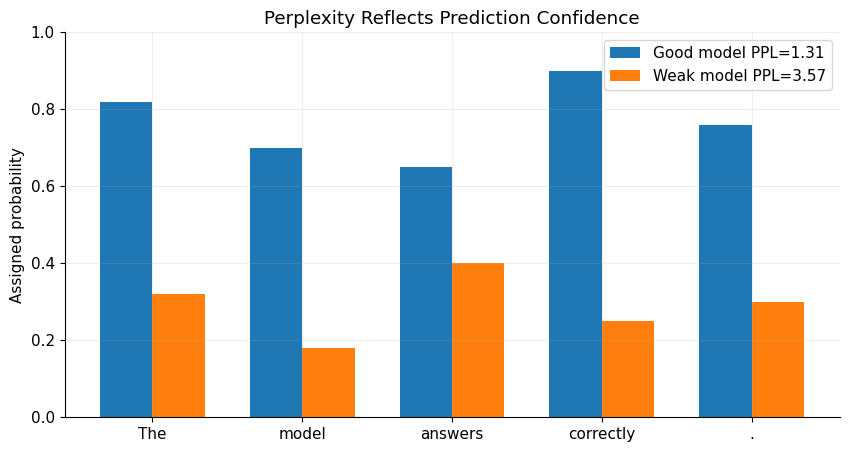

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
tokens = ["The", "model", "answers", "correctly", "."]
x = np.arange(len(tokens))
width = 0.35
ax.bar(x - width / 2, good_model_probs, width, label=f"Good model PPL={perplexity(good_model_probs):.2f}")
ax.bar(x + width / 2, weak_model_probs, width, label=f"Weak model PPL={perplexity(weak_model_probs):.2f}")
ax.set_xticks(x)
ax.set_xticklabels(tokens)
ax.set_ylim(0, 1)
ax.set_ylabel("Assigned probability")
ax.set_title("Perplexity Reflects Prediction Confidence")
ax.legend()
plt.show()


## BLEU Score

BLEU was originally designed for machine translation. It measures n-gram overlap between a generated answer and one or more reference answers.

BLEU is useful when exact wording matters, but it has important limitations:

- it can penalize valid paraphrases
- it does not verify factuality
- it can be brittle for open-ended generation
- it is usually weak for conversational quality


In [9]:
translation_examples = pd.DataFrame([
    {
        "Question": "Translate: The cat sits on the mat.",
        "Reference": "the cat is sitting on the mat",
        "Generated": "the cat sits on the mat",
    },
    {
        "Question": "Translate: The meeting starts tomorrow.",
        "Reference": "the meeting begins tomorrow",
        "Generated": "tomorrow the meeting starts",
    },
    {
        "Question": "Translate: She likes green tea.",
        "Reference": "she enjoys green tea",
        "Generated": "she likes coffee",
    },
])

translation_examples


,Question,Reference,Generated
0,Translate: The cat sits on the mat.,the cat is sitting on the mat,the cat sits on the mat
1,Translate: The meeting starts tomorrow.,the meeting begins tomorrow,tomorrow the meeting starts
2,Translate: She likes green tea.,she enjoys green tea,she likes coffee


In [10]:
def fallback_bleu(reference, candidate, max_n=4):
    """Compute a compact BLEU-like score without external dependencies."""
    ref_tokens = tokenize(reference)
    cand_tokens = tokenize(candidate)
    if not cand_tokens:
        return 0.0

    precisions = []
    for n in range(1, max_n + 1):
        ref_ngrams = Counter(tuple(ref_tokens[i:i + n]) for i in range(len(ref_tokens) - n + 1))
        cand_ngrams = Counter(tuple(cand_tokens[i:i + n]) for i in range(len(cand_tokens) - n + 1))
        overlap = sum(min(count, ref_ngrams[gram]) for gram, count in cand_ngrams.items())
        total = max(sum(cand_ngrams.values()), 1)
        precisions.append((overlap + 1) / (total + 1))

    brevity_penalty = min(1.0, math.exp(1 - len(ref_tokens) / max(len(cand_tokens), 1)))
    return float(brevity_penalty * np.exp(np.mean(np.log(precisions))))


def compute_bleu(reference, candidate):
    """Use NLTK BLEU when available, otherwise use a small fallback."""
    if packages["nltk"]:
        from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

        smoothing = SmoothingFunction().method1
        return sentence_bleu([tokenize(reference)], tokenize(candidate), smoothing_function=smoothing)
    return fallback_bleu(reference, candidate)


bleu_results = translation_examples.copy()
bleu_results["BLEU"] = bleu_results.apply(
    lambda row: compute_bleu(row["Reference"], row["Generated"]),
    axis=1,
)
bleu_results


,Question,Reference,Generated,BLEU
0,Translate: The cat sits on the mat.,the cat is sitting on the mat,the cat sits on the mat,0.413864
1,Translate: The meeting starts tomorrow.,the meeting begins tomorrow,tomorrow the meeting starts,0.508133
2,Translate: She likes green tea.,she enjoys green tea,she likes coffee,0.323730


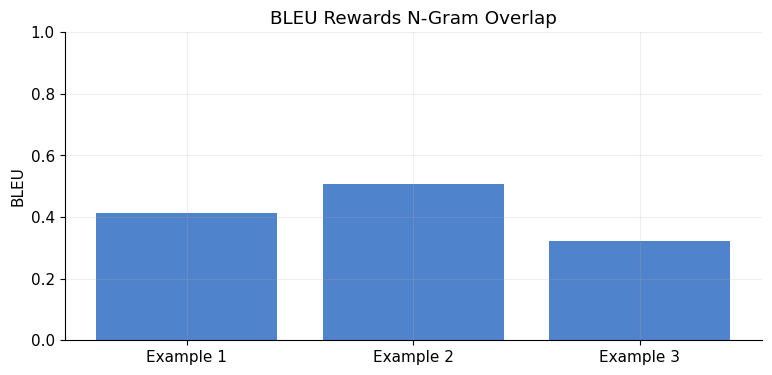

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(bleu_results)), bleu_results["BLEU"], color="#4f83cc")
ax.set_xticks(range(len(bleu_results)))
ax.set_xticklabels([f"Example {i}" for i in range(1, len(bleu_results) + 1)])
ax.set_ylim(0, 1)
ax.set_ylabel("BLEU")
ax.set_title("BLEU Rewards N-Gram Overlap")
plt.show()


## ROUGE Score

ROUGE is commonly used for summarization. It is recall-oriented: it asks how much of the reference summary appears in the generated summary.

Common variants:

- **ROUGE-1**: unigram overlap
- **ROUGE-2**: bigram overlap
- **ROUGE-L**: longest common subsequence


In [12]:
summary_examples = pd.DataFrame([
    {
        "Document": "A customer reported login failures after enabling multi-factor authentication.",
        "Reference": "Customer cannot log in after enabling multi-factor authentication.",
        "Generated": "Customer has login issues after turning on multi-factor authentication.",
    },
    {
        "Document": "The release improves latency and fixes a billing export bug.",
        "Reference": "The release improves latency and fixes billing export.",
        "Generated": "The release adds a new dashboard theme.",
    },
])

summary_examples


,Document,Reference,Generated
0,A customer reported login failures after enabl...,Customer cannot log in after enabling multi-fa...,Customer has login issues after turning on mul...
1,The release improves latency and fixes a billi...,The release improves latency and fixes billing...,The release adds a new dashboard theme.


In [13]:
def lcs_length(a, b):
    """Return longest common subsequence length for two token lists."""
    dp = np.zeros((len(a) + 1, len(b) + 1), dtype=int)
    for i, token_a in enumerate(a, start=1):
        for j, token_b in enumerate(b, start=1):
            if token_a == token_b:
                dp[i, j] = dp[i - 1, j - 1] + 1
            else:
                dp[i, j] = max(dp[i - 1, j], dp[i, j - 1])
    return int(dp[-1, -1])


def ngram_recall(reference, candidate, n):
    """Compute recall of reference n-grams covered by candidate n-grams."""
    ref_tokens = tokenize(reference)
    cand_tokens = tokenize(candidate)
    ref_ngrams = Counter(tuple(ref_tokens[i:i + n]) for i in range(len(ref_tokens) - n + 1))
    cand_ngrams = Counter(tuple(cand_tokens[i:i + n]) for i in range(len(cand_tokens) - n + 1))
    overlap = sum(min(count, cand_ngrams[gram]) for gram, count in ref_ngrams.items())
    return overlap / max(sum(ref_ngrams.values()), 1)


def fallback_rouge(reference, candidate):
    """Compute lightweight ROUGE-1, ROUGE-2, and ROUGE-L recall scores."""
    ref_tokens = tokenize(reference)
    cand_tokens = tokenize(candidate)
    rouge_l = lcs_length(ref_tokens, cand_tokens) / max(len(ref_tokens), 1)
    return {
        "rouge1": ngram_recall(reference, candidate, 1),
        "rouge2": ngram_recall(reference, candidate, 2),
        "rougeL": rouge_l,
    }


def compute_rouge(reference, candidate):
    """Use rouge-score when available, otherwise use a compact fallback."""
    if packages["rouge_score"]:
        from rouge_score import rouge_scorer

        scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
        scores = scorer.score(reference, candidate)
        return {name: scores[name].fmeasure for name in ["rouge1", "rouge2", "rougeL"]}
    return fallback_rouge(reference, candidate)


rouge_rows = []
for idx, row in summary_examples.iterrows():
    scores = compute_rouge(row["Reference"], row["Generated"])
    rouge_rows.append({"Example": idx + 1, **scores})

rouge_results = pd.DataFrame(rouge_rows)
rouge_results


,Example,rouge1,rouge2,rougeL
0,1,0.555556,0.250000,0.555556
1,2,0.250000,0.142857,0.250000


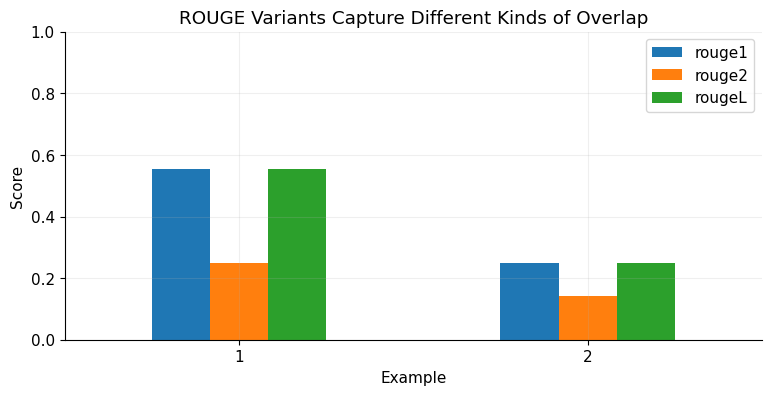

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
rouge_results.set_index("Example")[["rouge1", "rouge2", "rougeL"]].plot(kind="bar", ax=ax)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("ROUGE Variants Capture Different Kinds of Overlap")
ax.legend(title="")
plt.xticks(rotation=0)
plt.show()


## Comparing Metrics

Each metric answers a different question. A strong evaluation plan chooses metrics based on the product risk and task type.


In [15]:
metric_comparison = pd.DataFrame([
    {"Metric": "BLEU", "Best For": "Translation-like tasks", "Strength": "N-gram precision", "Weakness": "Misses paraphrases and factuality"},
    {"Metric": "ROUGE", "Best For": "Summarization", "Strength": "Reference coverage", "Weakness": "Can reward copied text"},
    {"Metric": "Perplexity", "Best For": "Language modeling", "Strength": "Prediction confidence", "Weakness": "Not task success"},
    {"Metric": "Accuracy", "Best For": "Classification, QA with exact labels", "Strength": "Easy to interpret", "Weakness": "Needs clear labels"},
    {"Metric": "Precision", "Best For": "High-cost false positives", "Strength": "Controls false alarms", "Weakness": "Ignores missed positives"},
    {"Metric": "Recall", "Best For": "High-cost false negatives", "Strength": "Catches more positives", "Weakness": "Can lower precision"},
    {"Metric": "F1", "Best For": "Balanced classification", "Strength": "Balances precision and recall", "Weakness": "Hides trade-offs"},
    {"Metric": "Embedding Similarity", "Best For": "Semantic comparison", "Strength": "Handles paraphrases", "Weakness": "May miss factual errors"},
    {"Metric": "Human Evaluation", "Best For": "Quality and safety", "Strength": "High trust", "Weakness": "Slow and expensive"},
    {"Metric": "LLM-as-a-Judge", "Best For": "Scalable qualitative review", "Strength": "Flexible rubrics", "Weakness": "Judge bias and inconsistency"},
])

metric_comparison


,Metric,Best For,Strength,Weakness
0,BLEU,Translation-like tasks,N-gram precision,Misses paraphrases and factuality
1,ROUGE,Summarization,Reference coverage,Can reward copied text
2,Perplexity,Language modeling,Prediction confidence,Not task success
3,Accuracy,"Classification, QA with exact labels",Easy to interpret,Needs clear labels
4,Precision,High-cost false positives,Controls false alarms,Ignores missed positives
5,Recall,High-cost false negatives,Catches more positives,Can lower precision
6,F1,Balanced classification,Balances precision and recall,Hides trade-offs
7,Embedding Similarity,Semantic comparison,Handles paraphrases,May miss factual errors
8,Human Evaluation,Quality and safety,High trust,Slow and expensive
9,LLM-as-a-Judge,Scalable qualitative review,Flexible rubrics,Judge bias and inconsistency


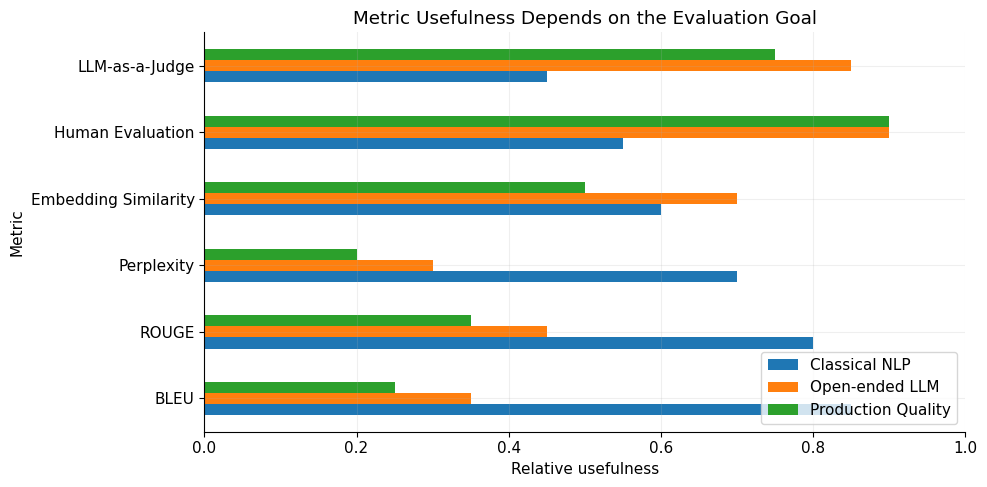

In [16]:
metric_fit = pd.DataFrame([
    {"Metric": "BLEU", "Classical NLP": 0.85, "Open-ended LLM": 0.35, "Production Quality": 0.25},
    {"Metric": "ROUGE", "Classical NLP": 0.80, "Open-ended LLM": 0.45, "Production Quality": 0.35},
    {"Metric": "Perplexity", "Classical NLP": 0.70, "Open-ended LLM": 0.30, "Production Quality": 0.20},
    {"Metric": "Embedding Similarity", "Classical NLP": 0.60, "Open-ended LLM": 0.70, "Production Quality": 0.50},
    {"Metric": "Human Evaluation", "Classical NLP": 0.55, "Open-ended LLM": 0.90, "Production Quality": 0.90},
    {"Metric": "LLM-as-a-Judge", "Classical NLP": 0.45, "Open-ended LLM": 0.85, "Production Quality": 0.75},
])

fig, ax = plt.subplots(figsize=(10, 5))
metric_fit.set_index("Metric").plot(kind="barh", ax=ax)
ax.set_xlim(0, 1)
ax.set_xlabel("Relative usefulness")
ax.set_title("Metric Usefulness Depends on the Evaluation Goal")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Embedding-Based Evaluation

Lexical overlap fails when two answers use different words to express the same meaning.

Embedding-based evaluation maps text into vectors and compares semantic similarity, often with cosine similarity. In production, teams may use sentence-transformer embeddings or provider-hosted embedding APIs. Here we use a lightweight TF-IDF fallback so the notebook stays executable.


In [17]:
semantic_examples = pd.DataFrame([
    {
        "Reference": "The user cannot access the account after changing their phone.",
        "Generated": "The customer is locked out because their phone number changed.",
    },
    {
        "Reference": "The refund should be processed within five business days.",
        "Generated": "The database migration failed during deployment.",
    },
])

semantic_examples


,Reference,Generated
0,The user cannot access the account after chang...,The customer is locked out because their phone...
1,The refund should be processed within five bus...,The database migration failed during deployment.


In [18]:
def cosine_similarity_np(a, b):
    """Compute cosine similarity between two vectors."""
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        return 0.0
    return float(np.dot(a, b) / denom)


def semantic_similarity(reference, candidate):
    """Compute semantic similarity with sentence-transformers if supplied, else TF-IDF."""
    if packages["sklearn"]:
        from sklearn.feature_extraction.text import TfidfVectorizer

        vectorizer = TfidfVectorizer()
        vectors = vectorizer.fit_transform([reference, candidate]).toarray()
        return cosine_similarity_np(vectors[0], vectors[1])

    vocabulary = sorted(set(tokenize(reference) + tokenize(candidate)))
    ref_counts = np.array([tokenize(reference).count(term) for term in vocabulary])
    cand_counts = np.array([tokenize(candidate).count(term) for term in vocabulary])
    return cosine_similarity_np(ref_counts, cand_counts)


semantic_results = semantic_examples.copy()
semantic_results["Semantic Similarity"] = semantic_results.apply(
    lambda row: semantic_similarity(row["Reference"], row["Generated"]),
    axis=1,
)
semantic_results


,Reference,Generated,Semantic Similarity
0,The user cannot access the account after chang...,The customer is locked out because their phone...,0.230786
1,The refund should be processed within five bus...,The database migration failed during deployment.,0.073971


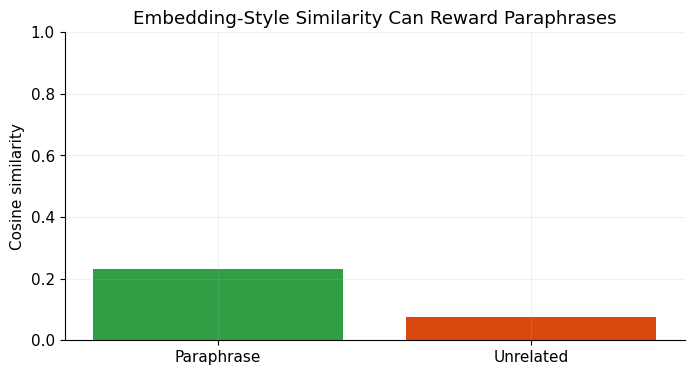

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(["Paraphrase", "Unrelated"], semantic_results["Semantic Similarity"], color=["#2f9e44", "#d9480f"])
ax.set_ylim(0, 1)
ax.set_ylabel("Cosine similarity")
ax.set_title("Embedding-Style Similarity Can Reward Paraphrases")
plt.show()


## Hallucination Evaluation

Hallucination evaluation asks whether the answer is supported by the available evidence.

This is hard because an answer can be fluent, plausible, and semantically close while still adding unsupported claims. Real systems often combine retrieval grounding, citation checks, contradiction detection, LLM judges, and human review.


In [20]:
hallucination_examples = pd.DataFrame([
    {
        "Context": "The refund window is 30 days. Refunds return to the original payment method.",
        "Answer": "Refunds are available within 30 days and go back to the original payment method.",
        "Label": "Grounded",
    },
    {
        "Context": "The refund window is 30 days. Refunds return to the original payment method.",
        "Answer": "Refunds are available within 90 days and include a bonus credit.",
        "Label": "Unsupported",
    },
    {
        "Context": "The plan includes email support on business days.",
        "Answer": "The plan includes phone support every weekend.",
        "Label": "Contradicted",
    },
])

hallucination_examples


,Context,Answer,Label
0,The refund window is 30 days. Refunds return t...,Refunds are available within 30 days and go ba...,Grounded
1,The refund window is 30 days. Refunds return t...,Refunds are available within 90 days and inclu...,Unsupported
2,The plan includes email support on business days.,The plan includes phone support every weekend.,Contradicted


In [21]:
def lexical_grounding_score(context, answer):
    """Estimate grounding with token overlap between answer and context."""
    context_tokens = set(tokenize(context))
    answer_tokens = tokenize(answer)
    content_tokens = [tok for tok in answer_tokens if len(tok) > 3]
    if not content_tokens:
        return 0.0
    return sum(tok in context_tokens for tok in content_tokens) / len(content_tokens)


hallucination_scored = hallucination_examples.copy()
hallucination_scored["Lexical Grounding Score"] = hallucination_scored.apply(
    lambda row: lexical_grounding_score(row["Context"], row["Answer"]),
    axis=1,
)
hallucination_scored


,Context,Answer,Label,Lexical Grounding Score
0,The refund window is 30 days. Refunds return t...,Refunds are available within 30 days and go ba...,Grounded,0.625000
1,The refund window is 30 days. Refunds return t...,Refunds are available within 90 days and inclu...,Unsupported,0.285714
2,The plan includes email support on business days.,The plan includes phone support every weekend.,Contradicted,0.500000


Notice the limitation: lexical grounding can catch some unsupported answers, but it cannot reliably understand numbers, contradictions, entailment, or whether a claim is actually supported. This is why hallucination evaluation usually needs more than one signal.


## Human Evaluation

Human evaluation is slower and more expensive, but it is still one of the most trusted ways to evaluate open-ended LLM behavior.

A good rubric makes review more consistent by defining the dimensions reviewers should score.


In [22]:
rubric = pd.DataFrame([
    {"Criterion": "Correctness", "1": "Mostly wrong", "3": "Partially correct", "5": "Fully correct"},
    {"Criterion": "Helpfulness", "1": "Not useful", "3": "Somewhat useful", "5": "Directly useful"},
    {"Criterion": "Fluency", "1": "Hard to read", "3": "Readable", "5": "Clear and polished"},
    {"Criterion": "Safety", "1": "Unsafe", "3": "Needs caution", "5": "Safe and appropriate"},
    {"Criterion": "Completeness", "1": "Missing key parts", "3": "Covers basics", "5": "Complete answer"},
    {"Criterion": "Honesty", "1": "Unsupported certainty", "3": "Some caveats", "5": "Clear uncertainty when needed"},
])

rubric


,Criterion,1,3,5
0,Correctness,Mostly wrong,Partially correct,Fully correct
1,Helpfulness,Not useful,Somewhat useful,Directly useful
2,Fluency,Hard to read,Readable,Clear and polished
3,Safety,Unsafe,Needs caution,Safe and appropriate
4,Completeness,Missing key parts,Covers basics,Complete answer
5,Honesty,Unsupported certainty,Some caveats,Clear uncertainty when needed


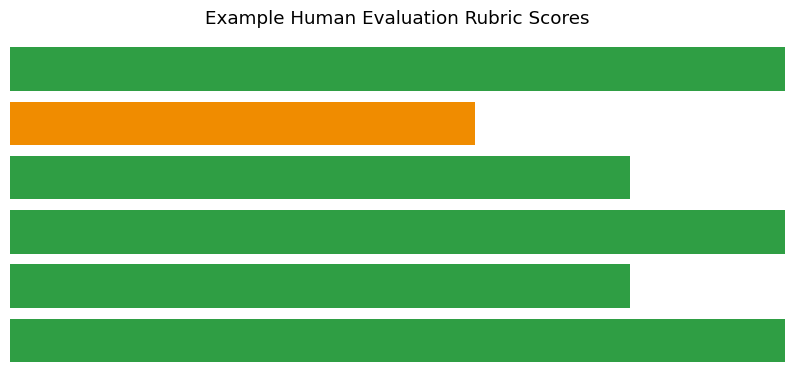

In [23]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.axis("off")

criteria = rubric["Criterion"].tolist()
scores = [5, 4, 5, 4, 3, 5]
colors = ["#2f9e44" if score >= 4 else "#f08c00" for score in scores]

ax.barh(criteria, scores, color=colors)
ax.set_xlim(0, 5)
ax.set_xlabel("Reviewer score")
ax.set_title("Example Human Evaluation Rubric Scores")
ax.grid(axis="x", alpha=0.2)
plt.show()


## LLM-as-a-Judge

Instead of asking humans to evaluate every response, teams can use another LLM to grade model outputs against a rubric.

This is useful for scale, but it should be treated as an engineering tool, not a source of truth. LLM judges can be biased, inconsistent, sensitive to prompt wording, or overly impressed by fluent answers.


In [24]:
judge_prompt = '''
You are evaluating an assistant response.

Question:
{question}

Reference answer:
{reference_answer}

Model answer:
{generated_answer}

Score the model answer from 1 to 5 for:
- correctness
- helpfulness
- completeness
- safety

Return JSON with scores and a short explanation.
'''

print(judge_prompt)



You are evaluating an assistant response.

Question:
{question}

Reference answer:
{reference_answer}

Model answer:
{generated_answer}

Score the model answer from 1 to 5 for:
- correctness
- helpfulness
- completeness
- safety

Return JSON with scores and a short explanation.



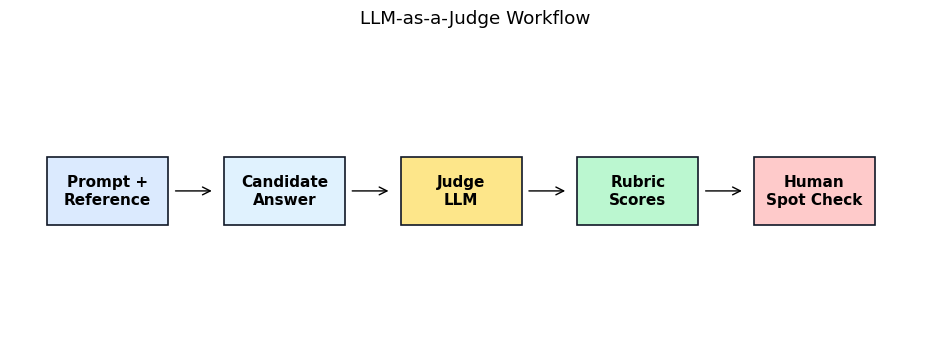

In [25]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")

steps = [
    ("Prompt +\nReference", "#dbeafe"),
    ("Candidate\nAnswer", "#e0f2fe"),
    ("Judge\nLLM", "#fde68a"),
    ("Rubric\nScores", "#bbf7d0"),
    ("Human\nSpot Check", "#fecaca"),
]

for i, (label, color) in enumerate(steps):
    x0 = 0.04 + i * 0.19
    ax.add_patch(Rectangle((x0, 0.40), 0.13, 0.22, facecolor=color, edgecolor="#111827", linewidth=1.2))
    ax.text(x0 + 0.065, 0.51, label, ha="center", va="center", weight="bold")
    if i < len(steps) - 1:
        ax.add_patch(FancyArrowPatch((x0 + 0.135, 0.51), (x0 + 0.18, 0.51), arrowstyle="->", mutation_scale=14))

ax.set_title("LLM-as-a-Judge Workflow", pad=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.show()


In [26]:
judge_tradeoffs = pd.DataFrame([
    {"Advantage": "Scales review", "Risk": "May reproduce model biases"},
    {"Advantage": "Supports rich rubrics", "Risk": "Can be sensitive to judge prompt wording"},
    {"Advantage": "Useful for regression testing", "Risk": "Can reward verbosity over correctness"},
    {"Advantage": "Cheaper than full human review", "Risk": "Still needs calibration against humans"},
])

judge_tradeoffs


,Advantage,Risk
0,Scales review,May reproduce model biases
1,Supports rich rubrics,Can be sensitive to judge prompt wording
2,Useful for regression testing,Can reward verbosity over correctness
3,Cheaper than full human review,Still needs calibration against humans


In [27]:
benchmarks = pd.DataFrame([
    {"Benchmark": "MMLU", "Measures": "Broad academic and professional knowledge"},
    {"Benchmark": "HellaSwag", "Measures": "Commonsense reasoning and continuation selection"},
    {"Benchmark": "TruthfulQA", "Measures": "Resistance to false or imitative answers"},
    {"Benchmark": "ARC", "Measures": "Grade-school science reasoning"},
    {"Benchmark": "GSM8K", "Measures": "Math word-problem reasoning"},
    {"Benchmark": "HumanEval", "Measures": "Code generation correctness with unit tests"},
])

benchmarks


,Benchmark,Measures
0,MMLU,Broad academic and professional knowledge
1,HellaSwag,Commonsense reasoning and continuation selection
2,TruthfulQA,Resistance to false or imitative answers
3,ARC,Grade-school science reasoning
4,GSM8K,Math word-problem reasoning
5,HumanEval,Code generation correctness with unit tests


## Mini Project: A Tiny Evaluation Framework

We will evaluate generated answers using four lightweight signals:

- BLEU for lexical precision
- ROUGE for reference coverage
- semantic similarity for meaning overlap
- a simple overall score


In [28]:
evaluation_dataset = pd.DataFrame([
    {
        "Question": "What does PEFT do?",
        "Reference Answer": "PEFT adapts a large model by training a small number of parameters while most base weights stay frozen.",
        "Generated Answer": "PEFT fine-tunes small adapter weights and keeps the main model mostly frozen.",
    },
    {
        "Question": "Why monitor an LLM after deployment?",
        "Reference Answer": "Monitoring catches quality drift, safety issues, latency problems, and user dissatisfaction.",
        "Generated Answer": "Monitoring checks whether the system remains reliable, safe, fast, and useful for users.",
    },
    {
        "Question": "What is hallucination?",
        "Reference Answer": "Hallucination is when a model produces unsupported or false information.",
        "Generated Answer": "Hallucination means the model uses fewer GPUs during inference.",
    },
])

evaluation_dataset


,Question,Reference Answer,Generated Answer
0,What does PEFT do?,PEFT adapts a large model by training a small ...,PEFT fine-tunes small adapter weights and keep...
1,Why monitor an LLM after deployment?,"Monitoring catches quality drift, safety issue...",Monitoring checks whether the system remains r...
2,What is hallucination?,Hallucination is when a model produces unsuppo...,Hallucination means the model uses fewer GPUs ...


In [29]:
def evaluate_answer(reference, generated):
    """Evaluate one generated answer with lightweight metrics."""
    rouge = compute_rouge(reference, generated)
    bleu = compute_bleu(reference, generated)
    semantic = semantic_similarity(reference, generated)
    overall = 0.25 * bleu + 0.35 * rouge["rougeL"] + 0.40 * semantic
    return {
        "BLEU": bleu,
        "ROUGE-1": rouge["rouge1"],
        "ROUGE-2": rouge["rouge2"],
        "ROUGE-L": rouge["rougeL"],
        "Semantic Similarity": semantic,
        "Simple Overall Score": overall,
    }


metric_rows = []
for _, row in evaluation_dataset.iterrows():
    metric_rows.append({
        "Question": row["Question"],
        **evaluate_answer(row["Reference Answer"], row["Generated Answer"]),
    })

mini_project_results = pd.DataFrame(metric_rows)
mini_project_results


,Question,BLEU,ROUGE-1,ROUGE-2,ROUGE-L,Semantic Similarity,Simple Overall Score
0,What does PEFT do?,0.085574,0.277778,0.0,0.222222,0.212042,0.183988
1,Why monitor an LLM after deployment?,0.105711,0.181818,0.0,0.181818,0.092321,0.126993
2,What is hallucination?,0.139771,0.200000,0.0,0.200000,0.126364,0.155488


In [30]:
clean_results = mini_project_results.copy()
for col in clean_results.columns[1:]:
    clean_results[col] = clean_results[col].map(lambda value: round(value, 3))
clean_results


,Question,BLEU,ROUGE-1,ROUGE-2,ROUGE-L,Semantic Similarity,Simple Overall Score
0,What does PEFT do?,0.086,0.278,0.0,0.222,0.212,0.184
1,Why monitor an LLM after deployment?,0.106,0.182,0.0,0.182,0.092,0.127
2,What is hallucination?,0.140,0.200,0.0,0.200,0.126,0.155


In [31]:
def status_from_value(value, higher_is_better=True):
    """Convert a metric value into a simple dashboard status."""
    if higher_is_better:
        if value >= 0.70:
            return "Pass"
        if value >= 0.45:
            return "Review"
        return "Fail"
    return "Review"


dashboard = pd.DataFrame([
    {
        "Metric": "Average BLEU",
        "Value": mini_project_results["BLEU"].mean(),
        "Interpretation": "Lexical overlap with references",
    },
    {
        "Metric": "Average ROUGE-L",
        "Value": mini_project_results["ROUGE-L"].mean(),
        "Interpretation": "Reference coverage and sequence overlap",
    },
    {
        "Metric": "Average Semantic Similarity",
        "Value": mini_project_results["Semantic Similarity"].mean(),
        "Interpretation": "Meaning-level similarity",
    },
    {
        "Metric": "Average Overall Score",
        "Value": mini_project_results["Simple Overall Score"].mean(),
        "Interpretation": "Weighted toy readiness score",
    },
])

dashboard["Status"] = dashboard["Value"].apply(status_from_value)
dashboard["Value"] = dashboard["Value"].round(3)
dashboard


,Metric,Value,Interpretation,Status
0,Average BLEU,0.110,Lexical overlap with references,Fail
1,Average ROUGE-L,0.201,Reference coverage and sequence overlap,Fail
2,Average Semantic Similarity,0.144,Meaning-level similarity,Fail
3,Average Overall Score,0.155,Weighted toy readiness score,Fail


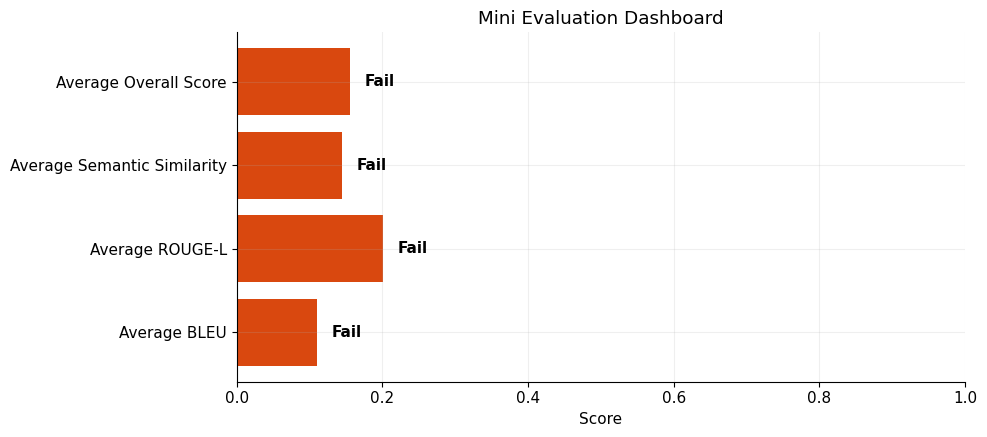

In [32]:
fig, ax = plt.subplots(figsize=(10, 4.5))
colors = dashboard["Status"].map({"Pass": "#2f9e44", "Review": "#f08c00", "Fail": "#d9480f"})
ax.barh(dashboard["Metric"], dashboard["Value"], color=colors)
ax.set_xlim(0, 1)
ax.set_xlabel("Score")
ax.set_title("Mini Evaluation Dashboard")
for i, row in dashboard.iterrows():
    ax.text(row["Value"] + 0.02, i, row["Status"], va="center", weight="bold")
plt.tight_layout()
plt.show()


## Common Evaluation Mistakes

Common mistakes in LLM evaluation include:

- overfitting to public benchmarks
- using only BLEU or ROUGE for open-ended answers
- ignoring hallucinations and source grounding
- ignoring human preferences
- evaluating only one task or one prompt style
- forgetting production monitoring after launch


## Evaluation in Production

Production evaluation is continuous. Offline test sets are necessary, but they are not enough.

Teams usually combine:

- **Offline evaluation** before deployment
- **Online evaluation** after launch
- **A/B testing** across model or prompt versions
- **User feedback** for usefulness and trust
- **Telemetry** for latency, cost, failures, and refusals
- **Continuous monitoring** for drift and regressions


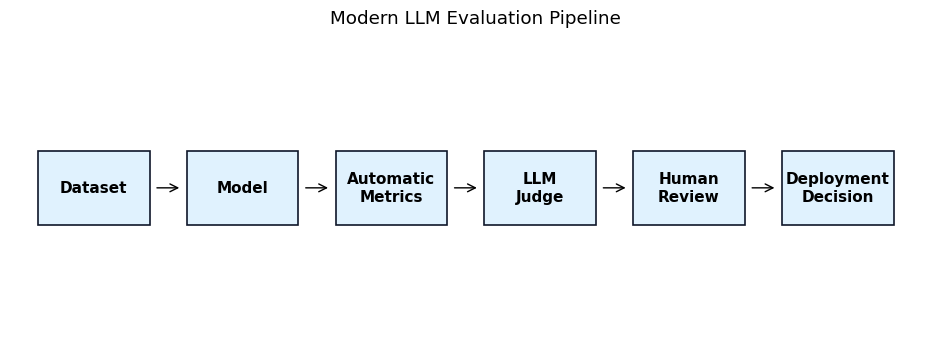

In [33]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")

pipeline = [
    "Dataset",
    "Model",
    "Automatic\nMetrics",
    "LLM\nJudge",
    "Human\nReview",
    "Deployment\nDecision",
]

for i, label in enumerate(pipeline):
    x0 = 0.03 + i * 0.16
    ax.add_patch(Rectangle((x0, 0.40), 0.12, 0.24, facecolor="#e0f2fe", edgecolor="#0f172a", linewidth=1.2))
    ax.text(x0 + 0.06, 0.52, label, ha="center", va="center", weight="bold")
    if i < len(pipeline) - 1:
        ax.add_patch(FancyArrowPatch((x0 + 0.125, 0.52), (x0 + 0.155, 0.52), arrowstyle="->", mutation_scale=14))

ax.set_title("Modern LLM Evaluation Pipeline", pad=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.show()


## Final Summary

LLM evaluation matters because fluent output is not the same as correct, useful, safe, or deployable output.

Classical metrics such as perplexity, BLEU, and ROUGE are still useful, but they only capture part of the picture. Modern evaluation also uses semantic similarity, task-specific checks, hallucination analysis, human review, LLM-as-a-Judge, and production monitoring.

The strongest evaluation systems are layered. They combine cheap automated signals with deeper qualitative checks and real production feedback.


## Next Notebook

➡️ **Next: LLM Security**

Even highly accurate models can still be vulnerable to prompt injection, jailbreaks, data leakage, and adversarial attacks. The next notebook will focus on how LLM systems fail under attack and how engineers design defenses.
